This file presents the utility method to bring the circuit into a ZX graph and try a basic optimization. There are several problems and constrains to use this method. The generation circuit should only have one set of measurements at the end of the circuit and no measurements during the emission circuit. We have to remove the measurements to convert the remaining stim.Circuit into a ZX circuit using stim_to_cirq and cirq to ZX. The optimization is not guaranteed to benifit the generation. The two main hopes is a simplified circuit with less emitter CNOTs and a more parrallel version of the circuit.

In [20]:
from pylab import *
import stim
import networkx as nx
import pyzx as zx
import stimcirq
import sys
sys.path.insert(0, '..')
from utils.zx_graph import *
from lib.tableau import *
from lib.circuitSolver import *

7
Circuit generates correct graph


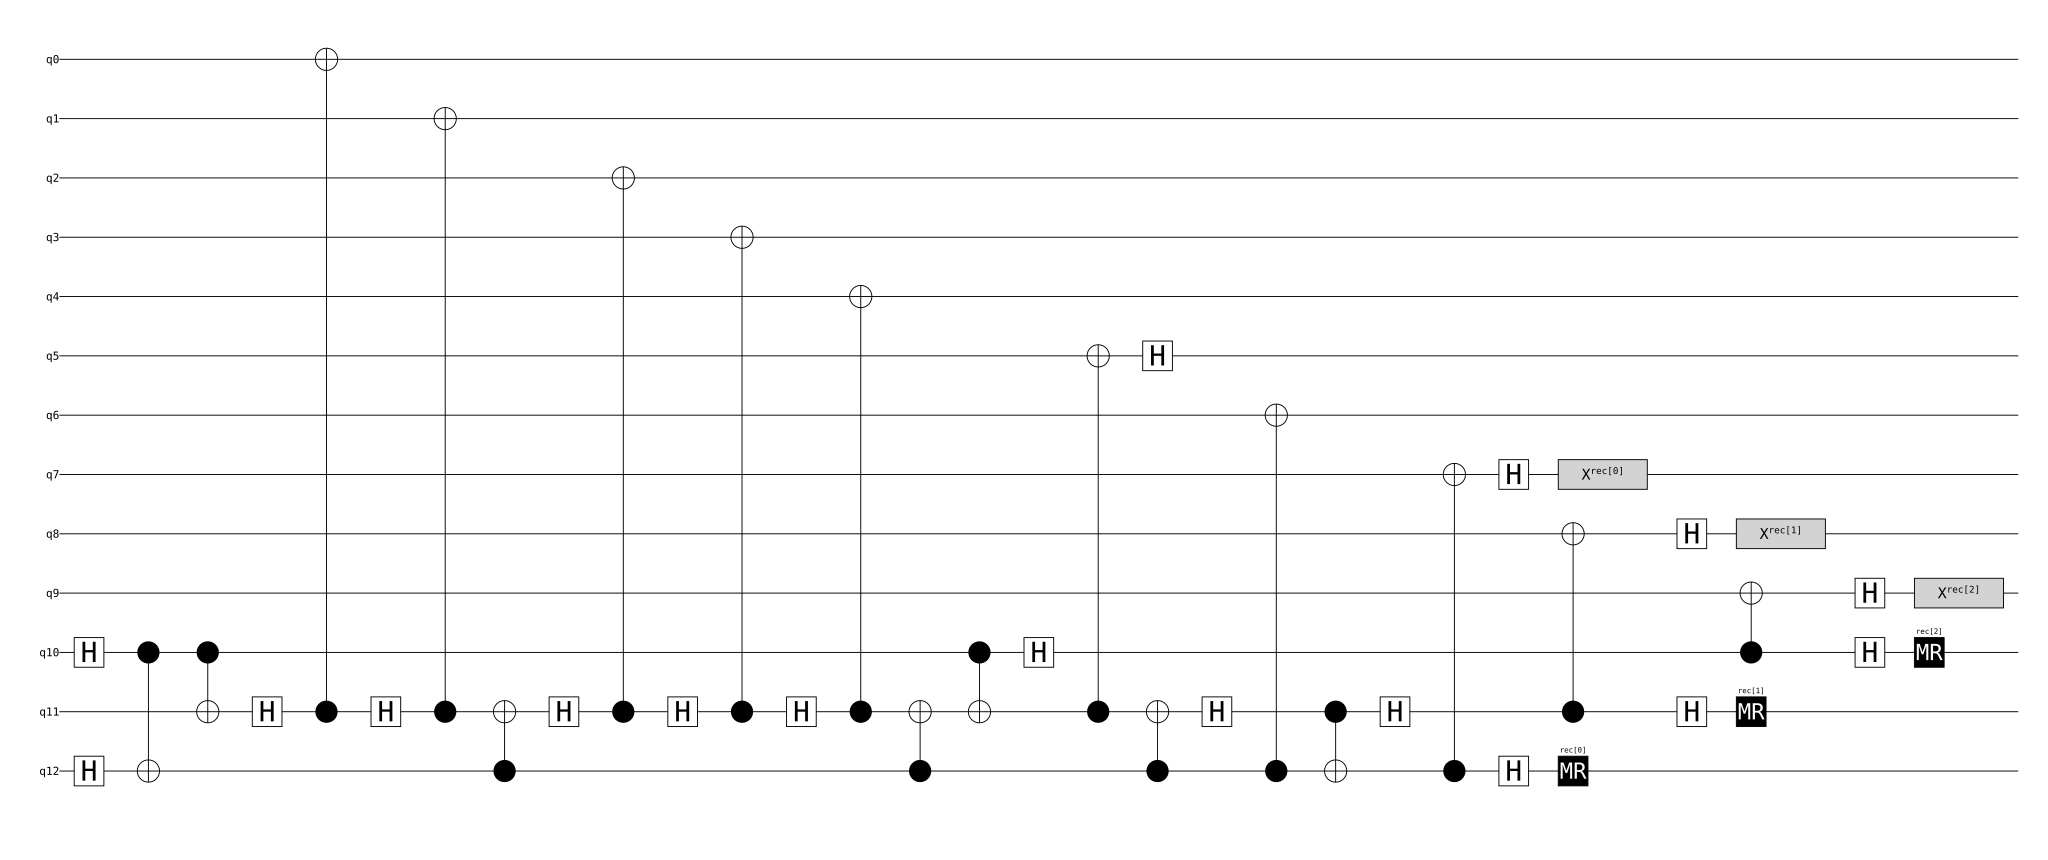

In [29]:
randomgraph = nx.newman_watts_strogatz_graph(10,2,0.5)
randomgraph_tab = stabTableau.get_tableau_from_graph(randomgraph)
operations,cnots = algorithm(randomgraph_tab,optimize=True,return_num_cnots=True)
print(cnots)
circuit = generationSequence(operations)
check = check_circuit(circuit,randomgraph_tab.pauliStrings0)
circuit.diagram('timeline-svg')

Circuit  on 13 qubits with 28 gates.
        0 is the T-count
        28 Cliffords among which
        17 2-qubit gates (17 CNOT, 0 other) and
        11 Hadamard gates.
Circuit  on 13 qubits with 28 gates.
        0 is the T-count
        28 Cliffords among which
        16 2-qubit gates (15 CNOT, 1 other) and
        9 Hadamard gates.


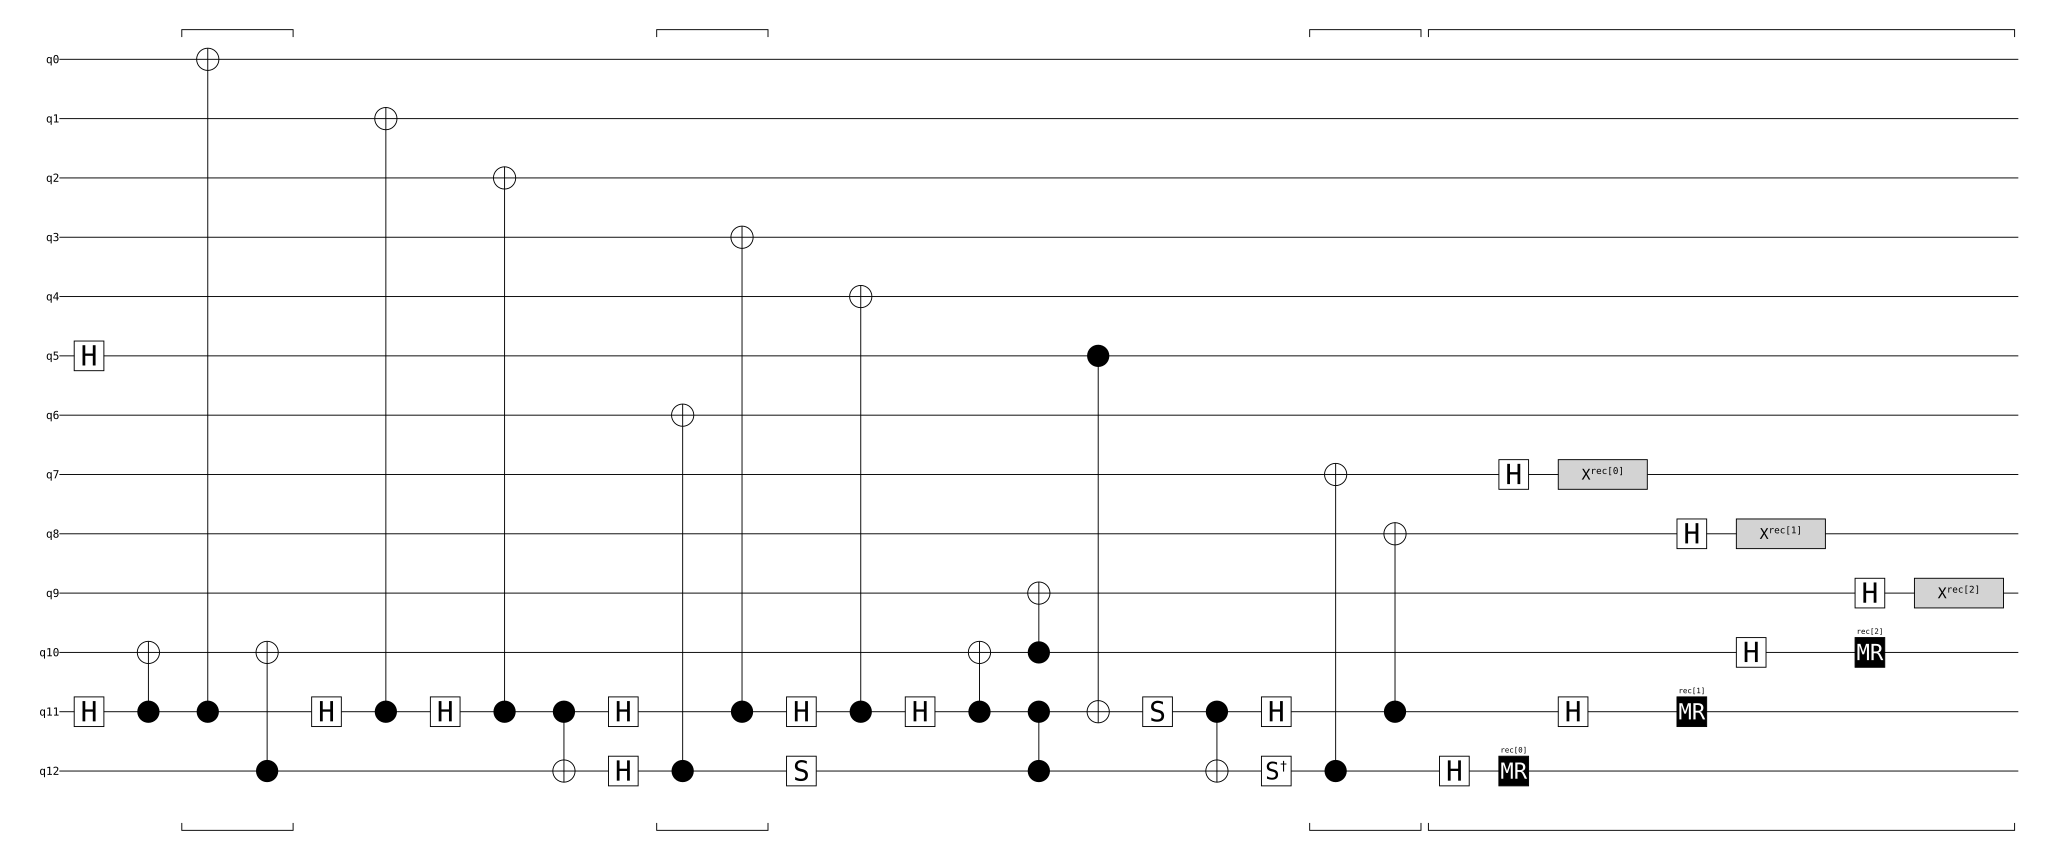

In [30]:
zx_optimization = ZXOptimization(circuit)
zx_optimization.circuit_wom.diagram('timeline-svg')
zx_optimization.try_zx_basic_opt()
print(zx_optimization.zx_circ.stats())
print(zx_optimization.zx_opt_circ.stats())

zx_optimization.zx_to_stim(zx_optimization.zx_opt_circ)
zx_optimization.opt_stim_circuit.diagram('timeline-svg')

now check the graph created by this circuit

In [31]:
check_circuit(zx_optimization.opt_stim_circuit,randomgraph_tab.pauliStrings0)

Circuit generates correct graph


array([False, False, False, False, False, False, False, False, False,
       False])

The brackets above the circuit show actions that could be done in parallel. And the number of two qubit gates might be reduced. There is a conversion error if there is a RZ gate with a different angle, then we can't convert it back to a stim.Circuit. And in some cases there are gates that gets pushed onto photons before emission, which should be avoided